# Analyse de sentiments - Modèle avancé

### Table des matières

* [**1. Introduction**](#chapter1)
* [**2. Préparation**](#chapter2)
    * [2.1. Import des données](#section_2_1)
    * [2.2. Définition des fonctions](#section_2_2)
    * [2.3. Sample](#section_2_3)  
    * [2.4. Preprocessing](#section_2_4)
    * [2.5. Jeu d'entrainement et de test](#section_2_5)
* [**3. Test des modèles**](#chapter3)
    * [3.1. Baseline](#section_3_1)
    * [3.2. Basic NN](#section_3_2)
    * [3.3. LSTM](#section_3_3)
    * [3.4. LSTM avec stemmatisation](#section_3_4)
    * [3.5. LSTM avec Lemmatisation](#section_3_5)
    * [3.6. LSTM avec word2vec](#section_3_6)
    * [3.7. LSTM avec glove](#section_3_7)
    * [3.8. LSTM Optimisation](#section_3_8)
    * [3.9. BERT](#section_3_9)
    * [3.10. Synthèse des résultats](#section_3_10)
* [**4. Pipeline**](#chapter4)
* [**5. Conclusion**](#chapter5)    

## 1 - Introduction <a class="anchor" id="chapter1"></a>

Dans ce notebook, pour prédire le sentiment de tweets, plusieurs modélisations à base de réseaux de neurones sont effectuées.  
Différents types de réseaux de neurones sont testés, ainsi que des plongements de mots et différents preprocessing.


## 2 - Préparation <a class="anchor" id="chapter2"></a>

### 2.1 - Import des données <a class="anchor" id="section_2_1"></a>

Import des données préalablement nettoyées lors de l'analyse exploratoire

In [8]:
import pandas as pd

data_path = "./sentiment140/"
datas = pd.read_csv(data_path + "sentiment_datas_cleaned.csv", delimiter=',', encoding = "ISO-8859-1")


In [21]:
datas

,label,id,text
0,0,1467810369,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,is upset that he can't update his Facebook by ...
2,0,1467810917,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,my whole body feels itchy and like its on fire
4,0,1467811193,"@nationwideclass no, it's not behaving at all...."
...,...,...,...
1581461,4,2193601966,Just woke up. Having no school is the best fee...
1581462,4,2193601969,TheWDB.com - Very cool to hear old Walt interv...
1581463,4,2193601991,Are you ready for your MoJo Makeover? Ask me f...
1581464,4,2193602064,Happy 38th Birthday to my boo of alll time!!! ...


### 2.2 - Définition des fonctions <a class="anchor" id="section_2_2"></a>

In [ ]:
# import des librairies

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,f1_score,classification_report
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

import tensorflow as tf

from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers import Embedding
from keras.layers import LSTM
from keras.callbacks import EarlyStopping

from transformers import BertTokenizer, TFBertModel, BertConfig, TFBertForSequenceClassification

from gensim import models

%matplotlib inline
sns.set()

In [67]:
# sample
def sample_datas(n): 
    datas_0 = datas[datas['label']==0].sample(n//2)
    datas_4 = datas[datas['label']==4].sample(n//2)
    return pd.concat([datas_0,datas_4])

# fonctions de preprocessing
%run -i ./preprocess_functions.py

In [68]:
# datas preparation

def tokenize_pad(x_train, x_test, seq_length):

    #Tokenize the sentences
    tokenizer = Tokenizer()

    #preparing vocabulary
    tokenizer.fit_on_texts(list(x_train))

    #converting text into integer sequences
    x_train  = tokenizer.texts_to_sequences(x_train) 
    x_test = tokenizer.texts_to_sequences(x_test)

    #padding to prepare sequences of same length
    x_train  = pad_sequences(x_train, maxlen=seq_length)
    x_test = pad_sequences(x_test, maxlen=seq_length)
    
    return x_train, x_test, tokenizer

def reshape_label(y_train, y_test):
    
    y_train = np.array(y_train).reshape(-1,1)
    y_test = np.array(y_test).reshape(-1,1)
    
    return y_train, y_test


In [69]:
# keras models

def basic_nn_model(embedding):
    
    model = Sequential()
    model.add(embedding)
    model.add(Flatten())
    model.add(Dense(16, activation='relu'))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy',optimizer='adam', metrics=['accuracy'])
    
    return model
    
def lstm_model(embedding, dropout=0.2, recurrent_dropout=0.2):
   
    model = Sequential()
    model.add(embedding)
    model.add(LSTM(100, dropout=dropout, recurrent_dropout=dropout))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss = 'binary_crossentropy', optimizer='adam',metrics = ['accuracy'])
    
    return model    

def epochs_train(epoch_es, epoch_init):
    return epoch_es + 1 if epoch_es>0 else epoch_init 


In [70]:
# embedding functions

def glove_embedding_layer(glove, tokenizer):

    vocab_size = len(tokenizer.word_index) + 1 
    embedding_matrix_glove = np.zeros((vocab_size, 100))

    for word, i in tokenizer.word_index.items():
        embedding_vector = glove.get(word)
        if embedding_vector is not None:
            embedding_matrix_glove[i] = embedding_vector

    embedding_vector_length = 100
    input_length = 100
    embedding_glove = Embedding(
        vocab_size,
        embedding_vector_length,
        weights=[embedding_matrix_glove],
        input_length=input_length,
        trainable=False) 
    
    return embedding_glove

def w2vec_embedding_layer(w2v, tokenizer):

    vocab_size = len(tokenizer.word_index) + 1 
    embedding_matrix_w2vec = np.zeros((vocab_size, 300))

    for word, i in tokenizer.word_index.items():
        if word in w2v.index_to_key:
            embedding_matrix_w2vec[i] = w2v.get_vector(word)
            
    embedding_vector_length = 300
    input_length = 300
    embedding_w2v = Embedding(
        vocab_size,
        embedding_vector_length,
        weights=[embedding_matrix_w2vec],
        input_length=input_length,
        trainable=False)         
        
    return embedding_w2v


In [71]:
# result functions

    
def plot_hist(hist):
    
    plt.figure(figsize=(15,5))
    plt.subplot(1,2,1)
    plot_accuracy_hist(hist)
    plt.subplot(1,2,2)
    plot_loss_hist(hist)
    plt.show()         
    
    
def plot_accuracy_hist(hist):

    acc = hist.history['accuracy']
    val = hist.history['val_accuracy']
    epochs = range(1, len(acc) + 1)

    plt.plot(epochs, acc, '-', label='Training accuracy')
    plt.plot(epochs, val, ':', label='Validation accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    ax = plt.gca()
    ax.set_ylim([0, 1])    


def plot_loss_hist(hist):
    
    loss = hist.history['loss']
    val_loss = hist.history['val_loss']
    epochs = range(1, len(loss) + 1)

    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss')
    ax = plt.gca()
    ax.set_ylim([0, 1])    
    plt.legend()   
    

def add_results(results, model_name, preprocess, embedding, dropout, epochs, sample, accuracy, fit_time, eval_time):
    
    result={}    
    result['model'] = model_name
    result['preprocess'] = preprocess
    result['embedding'] = embedding
    result['dropout'] = dropout
    result['epochs'] = epochs
    result['sample'] = sample
    result['accuracy'] = accuracy
    result['fit_time'] = fit_time
    result['eval_time'] = eval_time
    results = results.append(result,ignore_index=True)
    
    return results



### 2.3 - Sample <a class="anchor" id="section_2_3"></a>

Extraction d'un échantillons de 10000 tweets

In [73]:
datas_sample = sample_datas(10000)

### 2.4 - Preprocessing <a class="anchor" id="section_2_4"></a>

Application des fonctions de preprocessing définies dans le fichier preprocess_functions.py  
Création de 3 colonnes : nettoyage seul, avec stemmatisation, avec lemmatisation 

In [74]:

datas_sample['text_clean'] = datas_sample['text'].apply(lambda x: preprocess(x, None))
datas_sample['text_clean_stem'] = datas_sample['text'].apply(lambda x: preprocess(x, 'stem'))
datas_sample['text_clean_lem'] = datas_sample['text'].apply(lambda x: preprocess(x, 'lem'))

preprocess_label_dict = {0:0, 4:1}
datas_sample['label'] = datas_sample['label'].map(preprocess_label_dict)


In [136]:
datas_sample

,label,id,text,text_clean,text_clean_stem,text_clean_lem
508505,0,2191382730,glad i get out of babysitting!! but now i hav...,glad get babysitting clean house,glad get babysit clean hous,glad get babysitting clean house
425970,0,2065097077,Federer wants it bad. kickin some ass @ the Fr...,federer wants bad kickin ass french open oh mi...,feder want bad kickin ass french open oh miss ...,federer want bad kickin as french open oh miss...
762594,0,2321528507,@LegitLenaa miss you too babycakes.,miss babycakes,miss babycak,miss babycakes
497737,0,2188757531,#haveyouever tried mixing in peanut butter int...,haveyouever tried mixing peanut butter chocola...,haveyouev tri mix peanut butter chocol milk do...,haveyouever try mix peanut butter chocolate mi...
135612,0,1880576346,packing to go home for summer!,packing go home summer,pack go home summer,pack go home summer
...,...,...,...,...,...,...
1482238,1,2071118369,omgomgomg. New internet possibly soon,omgomgomg new internet possibly soon,omgomgomg new internet possibl soon,omgomgomg new internet possibly soon
1361108,1,2052015102,@jcluvsnkotb Danny...always been Danny...so ho...,dannyalways dannyso hot,dannyalway dannyso hot,dannyalways dannyso hot
1054311,1,1965878587,Lalalala shoppin wit my larry,lalalala shoppin wit larry,lalalala shoppin wit larri,lalalala shoppin wit larry
788826,1,1467986425,@JonathanRKnight You are so right for saying t...,right saying good said good night xoxo,right say good said good night xoxo,right say good say good night xoxo


### 2.5 - Jeu d'entrainement et de test <a class="anchor" id="section_2_5"></a>

Séparation en un jeu de données et un jeu de test

In [75]:

train_size = 0.8
df_train, df_test = train_test_split(datas_sample, test_size=1-train_size, random_state=42, stratify=datas_sample['label'])


## 3 - Test des modèles <a class="anchor" id="chapter3"></a>

Différents modèles vont être testés.  
Pour les évaluer, la métrique accuracy est adaptée, le jeu de données étant équilibré.   
Les temps d'entrainement et de prédiction sont aussi mesurés.

### 3.1 - Baseline <a class="anchor" id="section_3_1"></a>

Avant d'effectuer l'analyse de sentiments avec des réseaux de neurones,  
une baseline est établez avec le modèle de classification Naive Bayes.


Les résultas de chaque modèle sont enregistrés dans la datframe result.

In [30]:
results = pd.DataFrame(columns=['model', 'preprocess', 'embedding', 'dropout', 'epochs', 'sample', 'accuracy','fit_time','eval_time'])


Utilisation du texte nettoyé seul  
Séparation des données et du label

In [31]:
x_train = df_train['text_clean']
x_test = df_test['text_clean']

y_train = df_train['label']
y_test = df_test['label']

Les données en entrée sont vectorisée en Bag of words.  
Le modèle utilisé est multinomial, adapté à la classification.  
Entrainement puis évaluation du modèle avec calcul du temps à chaque étape.

In [32]:

vec = CountVectorizer()
x_train_vec = vec.fit_transform(x_train).toarray()
x_test_vec = vec.transform(x_test).toarray()

model_nb = MultinomialNB()

start_time = time.time()
model_nb.fit(x_train_vec, y_train)
fit_time = time.time() - start_time

start_time = time.time()
score = model_nb.score(x_test_vec, y_test)
eval_time = time.time() - start_time

# add to results
results = add_results(results, 'Naive Bayes', 'clean_only', '', '', '', 20000, score, fit_time, eval_time)



In [33]:
results

,model,preprocess,embedding,dropout,epochs,sample,accuracy,fit_time,eval_time
0,Naive Bayes,clean_only,,,,20000,0.716,1.931133,0.125663


Le score est de 0.71, ce qui est un bon score.  
L'entrainement est très rapide, moins de 2 secondes.

### 3.2 - Basic NN <a class="anchor" id="section_3_2"></a>

Le premier réseau de neurones utilisé est un réseau basé sur des couches dense fully connected.  
La première couche est la couche Embedding de Keras  
qui sera entrainée avec le modèle pour la vectorisation en plongement de mots.

Préparation des données:  
    - preprocessing simple  
    - tokenisation des phrases  
    - transformation en séquences de taille fixe  
    - préparation de la couche embedding  

In [34]:
# preprocess text
x_train = df_train['text_clean']
x_test = df_test['text_clean']

# prepare data
input_length = 300
x_train, x_test, tokenizer = tokenize_pad(x_train, x_test, input_length)
y_train, y_test = reshape_label(y_train,y_test)

# embedding layer
vocab_size = len(tokenizer.word_index) + 1 
embedding_vector_length = 32
embedding = Embedding(
    vocab_size, 
    embedding_vector_length, 
    input_length=input_length
)


Entrainement et évaluation du modèle  
Affichage de l'historique Accuracy et Loss  

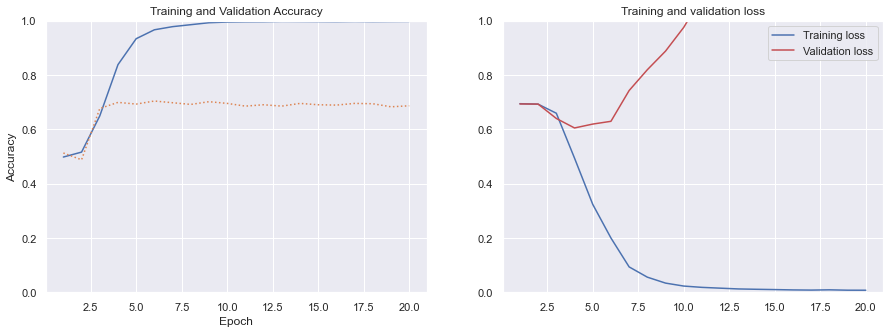

Accuracy: 69.35%


In [35]:
# create model
model_basic = basic_nn_model(embedding)

# fit model
start_time = time.time()
hist_basic = model_basic.fit(x_train, y_train, validation_split=0.1, epochs=20, batch_size=128, verbose = 0)
fit_time = time.time() - start_time

# evaluate model
start_time = time.time()
scores = model_basic.evaluate(x_test, y_test, verbose=0)
eval_time = time.time() - start_time

# plot history
plot_hist(hist_basic)
print("Accuracy: %.2f%%" % (scores[1] * 100))



Il y a une différence importante entre l'entrainement et la validation au bout de 3 epochs.  
De même, la courbe loss de la validation augmente beaucoup après 4 epochs.  
Le modèle est en overfitting.  
Il est inutile de continuer l'entrainement au delà.  

Ajout d'un EarlyStopping pour stopper l'entrainement

In [36]:

es = EarlyStopping(
    monitor='val_accuracy', 
    patience=5, 
    min_delta=0.001
)

nb_epochs_init = 20


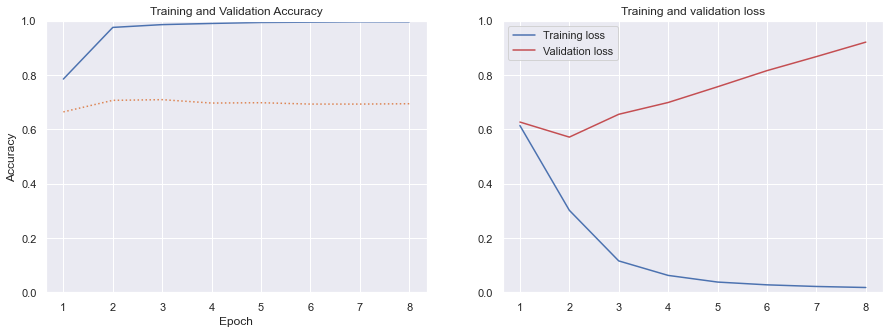

Accuracy: 69.65%


In [37]:


# create model
model_basic2 = basic_nn_model(embedding)

# fit model
start_time = time.time()
hist_basic = model_basic2.fit(
    x_train, 
    y_train, 
    validation_split=0.1, 
    epochs=nb_epochs_init, 
    batch_size=128, 
    verbose = 0, 
    callbacks=[es]
)
nb_epochs_train = epochs_train(es.stopped_epoch, nb_epochs_init)
fit_time = time.time() - start_time

# evaluate model
start_time = time.time()
scores = model_basic2.evaluate(x_test, y_test, verbose=0)
eval_time = time.time() - start_time

# plot history
plot_hist(hist_basic)
print("Accuracy: %.2f%%" % (scores[1] * 100))



L'entrainement s'est arrêté à 8 epochs, au lieu de 20.  
Il y a toujours un overfitting.  
Ce modèle pourra servir de comparaison avec des réseaux de neurones LSTM.  

Enregistrement des résultats:  

In [38]:
# add to results
results = add_results(results, 'basic', 'clean_only', 'inline', '', nb_epochs_train, 20000, scores[1], fit_time, eval_time)


### 3.3 - LSTM <a class="anchor" id="section_3_3"></a>

Les réseaux LSTM sont de réseaux de neurones mieux adaptés à l'analyse de texte.  
Ces réseaux ont une fonction de mémorisation, permettant de prendre en compte les mots dans le contexte de la phrase.  

Utilisation d'un EarlyStopping, comme pour le modèle précédent.  
Ces réseaux de neurones sont beaucoup plus lents à entrainer.  
L'entrainement est effectué avec 5 epochs.

In [39]:
es = EarlyStopping(
    monitor='val_accuracy', 
    patience=2, 
    min_delta=0.001
)

nb_epochs_init = 5

Création du modèle, entrainement, évaluation et affichage de l'historique, comme pour le modèle précédent.  
Les données d'entrainement et de test sont les mêmes que pour le modèle précédent (prepocessing simple).

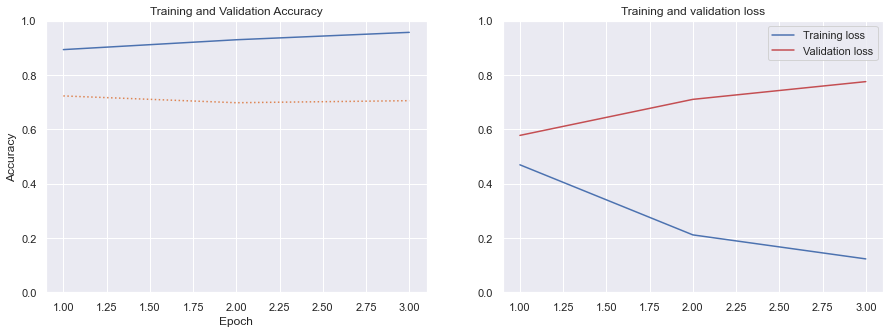

Accuracy: 71.60%


In [40]:

# create model
model_lstm = lstm_model(embedding)

# fit model
start_time = time.time()
hist_lstm = model_lstm.fit(
    x_train, 
    y_train, 
    validation_split=0.1, 
    epochs=nb_epochs_init, 
    batch_size=128, 
    verbose = 0, 
    callbacks=[es]
)
nb_epochs_train = epochs_train(es.stopped_epoch, nb_epochs_init)
fit_time = time.time() - start_time

# evaluate model
start_time = time.time()
scores = model_lstm.evaluate(x_test, y_test, verbose=0)
eval_time = time.time() - start_time


# plot history
plot_hist(hist_lstm)
print("Accuracy: %.2f%%" % (scores[1] * 100))



Le phénomène d'overfitting est toujours présent.  
La précision est meilleure.  

In [41]:
# add to results
results = add_results(results, 'lstm', 'clean_only', 'inline', '0.2', nb_epochs_train, 20000, scores[1], fit_time, eval_time)


### 3.4 - LSTM avec stemmatisation <a class="anchor" id="section_3_4"></a>

Test du modèle LSTM avec les données stemmatisées.  

In [42]:
# preprocess text
x_train = df_train['text_clean_stem']
x_test = df_test['text_clean_stem']

# prepare data
input_length = 300
x_train, x_test, tokenizer = tokenize_pad(x_train, x_test, input_length)
y_train, y_test = reshape_label(y_train,y_test)

# embedding layer
vocab_size = len(tokenizer.word_index) + 1 
embedding_vector_length = 32
embedding = Embedding(
    vocab_size, 
    embedding_vector_length, 
    input_length=input_length
)

es = EarlyStopping(
    monitor='val_accuracy', 
    patience=2, 
    min_delta=0.001
)


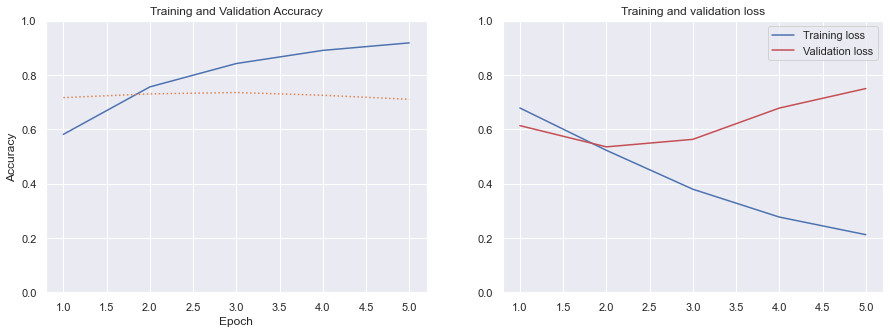

Accuracy: 71.05%


In [43]:
# create model
model_lstm = lstm_model(embedding)

# fit model
start_time = time.time()
hist_lstm = model_lstm.fit(
    x_train, 
    y_train, 
    validation_split=0.1, 
    epochs=nb_epochs_init, 
    batch_size=128, 
    verbose = 0, 
    callbacks=[es]
)
nb_epochs_train = epochs_train(es.stopped_epoch, nb_epochs_init)
fit_time = time.time() - start_time

# evaluate model
start_time = time.time()
scores = model_lstm.evaluate(x_test, y_test, verbose=0)
eval_time = time.time() - start_time

# plot history
plot_hist(hist_lstm)
print("Accuracy: %.2f%%" % (scores[1] * 100))



Les résultats sont similaires au test précédent sans stemmatisation

In [44]:
# add to results
results = add_results(results, 'lstm', 'stem', 'inline', '0.2', nb_epochs_train, 20000, scores[1], fit_time, eval_time)


### 3.5 - LSTM <a class="anchor" id="section_3_5"></a>

Test avec les données lemmatisées

In [45]:

# preprocess text
x_train = df_train['text_clean_lem']
x_test = df_test['text_clean_lem']

# prepare data
input_length = 300
x_train, x_test, tokenizer = tokenize_pad(x_train, x_test, input_length)
y_train, y_test = reshape_label(y_train,y_test)

# embedding layer
vocab_size = len(tokenizer.word_index) + 1 
embedding_vector_length = 32
embedding = Embedding(
    vocab_size, 
    embedding_vector_length, 
    input_length=input_length
)

es = EarlyStopping(
    monitor='val_accuracy', 
    patience=2, 
    min_delta=0.001
)


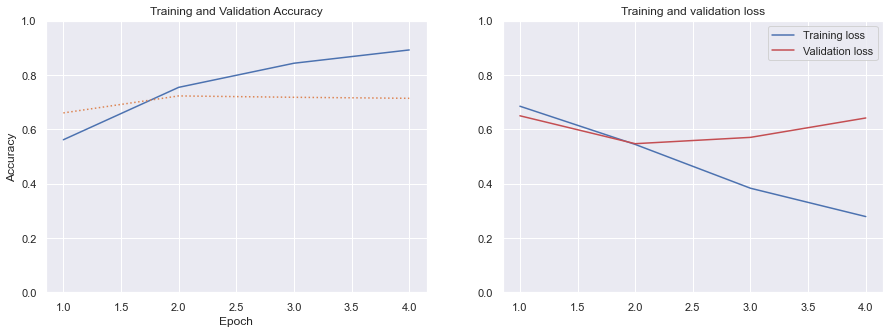

Accuracy: 71.20%


In [46]:

# create model
model_lstm = lstm_model(embedding)

# fit model
start_time = time.time()
hist_lstm = model_lstm.fit(
    x_train, 
    y_train, 
    validation_split=0.1, 
    epochs=nb_epochs_init, 
    batch_size=128, 
    verbose = 0, 
    callbacks=[es]
)
nb_epochs_train = epochs_train(es.stopped_epoch, nb_epochs_init)
fit_time = time.time() - start_time

# evaluate model
start_time = time.time()
scores = model_lstm.evaluate(x_test, y_test, verbose=0)
eval_time = time.time() - start_time

# plot history
plot_hist(hist_lstm)
print("Accuracy: %.2f%%" % (scores[1] * 100))



Les résultats sont similaires à la stemmatisation.  
Le score est un peu meilleur. De plus:  
La lemmatisation ne prend pas que la racine du mot, la lemmatisation est plus informative.    
Les modélisations suivantes seront effectuées avec les mots lemmatisés.  

In [47]:
# add to results
results = add_results(results, 'lstm', 'lem', 'inline', '0.2', nb_epochs_train, 20000, scores[1], fit_time, eval_time)

### 3.6 - LSTM avec wor2vec <a class="anchor" id="section_3_6"></a>

Le modèle LSTM va maintenant être effectué avec des word embedding pré entrainés.  
Le premier utilisé est word2vec.  

Chargement du fichier

In [48]:

w2v = models.KeyedVectors.load_word2vec_format(
    './data/GoogleNews-vectors-negative300.bin/GoogleNews-vectors-negative300.bin', binary=True)
print('Loaded %s word vectors.' % len(w2v))

Loaded 3000000 word vectors.


Préparation des données.  
Une couche embedding est créée avec une association de chaque mot du vocabulaire de notre jeu de données  
avec le vecteur word2vec correspondant.

In [52]:

# preprocess text
x_train = df_train['text_clean_lem']
x_test = df_test['text_clean_lem']

# prepare data
x_train, x_test, tokenizer = tokenize_pad(x_train, x_test, 300)
y_train, y_test = reshape_label(y_train,y_test)

# embedding layer
embedding_w2v = w2vec_embedding_layer(w2v, tokenizer)

es = EarlyStopping(
    monitor='val_accuracy', 
    patience=2, 
    min_delta=0.001
)


Création, entrainement et évaluation du modèle

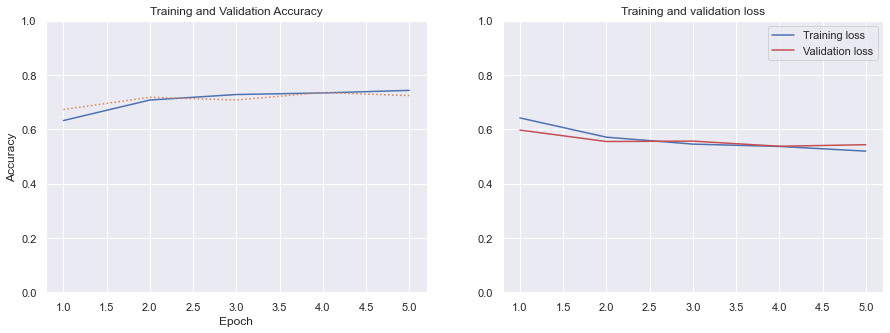

Accuracy: 72.10%


In [53]:

# create model
model_lstm_w2vec = lstm_model(embedding_w2v)

# fit model
start_time = time.time()
hist_lstm_w2vec = model_lstm_w2vec.fit(
    x_train, 
    y_train, 
    validation_split=0.1, 
    epochs=nb_epochs_init, 
    batch_size=128, 
    verbose = 0, 
    callbacks=[es]
)
nb_epochs_train = epochs_train(es.stopped_epoch, nb_epochs_init)
fit_time = time.time() - start_time

# evaluate model
start_time = time.time()
scores = model_lstm_w2vec.evaluate(x_test, y_test, verbose=0)
eval_time = time.time() - start_time

# plot history
plot_hist(hist_lstm_w2vec)
print("Accuracy: %.2f%%" % (scores[1] * 100))


Le score est meilleur.  
Les courbes d'entrainement et de validation se suivent.  


In [54]:
# add to results
results = add_results(results, 'lstm', 'lem', 'w2vec', '0.2', nb_epochs_train, 20000, scores[1], fit_time, eval_time)


### 3.7 - LSTM avec glove <a class="anchor" id="section_3_7"></a>

Test avec le plongement de mots pré entrainé glove.  
Les vecteurs utilisés ont une dimension de 100 (contre 300 dans le test précédent avec word2vec).  
C'est un fichier de résultats sur des données de twitter.

In [14]:
f = open('./data/glove.twitter.27B/glove.twitter.27B.100d.txt', encoding = "utf-8")

glove = dict()
for line in f:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:], dtype='float32')
    glove[word] = coefs

f.close()

print('Loaded %s word vectors.' % len(glove))

Loaded 1193514 word vectors.


In [56]:

# preprocess text
x_train = df_train['text_clean_lem']
x_test = df_test['text_clean_lem']

# prepare data
x_train, x_test, tokenizer = tokenize_pad(x_train, x_test, 100)
y_train, y_test = reshape_label(y_train,y_test)

# embedding layer
embedding_glove = glove_embedding_layer(glove, tokenizer)

es = EarlyStopping(
    monitor='val_accuracy', 
    patience=2, 
    min_delta=0.001
)


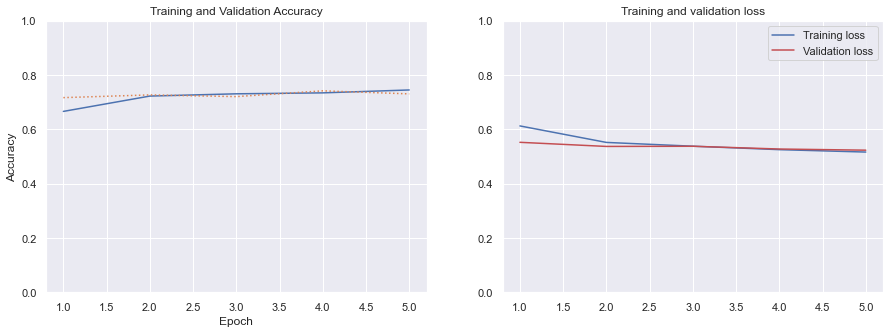

Accuracy: 72.25%


In [57]:

# create model
model_lstm_glove = lstm_model(embedding_glove)

# fit model
start_time = time.time()
hist_lstm_glove = model_lstm_glove.fit(
    x_train, 
    y_train, 
    validation_split=0.1, 
    epochs=nb_epochs_init, 
    batch_size=128, 
    verbose = 0, 
    callbacks=[es]
)
nb_epochs_train = epochs_train(es.stopped_epoch, nb_epochs_init)
fit_time = time.time() - start_time

# evaluate model
start_time = time.time()
scores = model_lstm_glove.evaluate(x_test, y_test, verbose=0)
eval_time = time.time() - start_time

# plot history
plot_hist(hist_lstm_glove)
print("Accuracy: %.2f%%" % (scores[1] * 100))


Les résultats sont similaires à ceux du modèle avec word2vec.  
Le temps d'entrainement est plus court.  
(cf tableau de résultats récapitulatif à la fin du notebook)


In [58]:
# add to results
results = add_results(results, 'lstm', 'lem', 'glove', '0.2', nb_epochs_train, 20000, scores[1], fit_time, eval_time)


### 3.8 - LSTM Optimisation <a class="anchor" id="section_3_8"></a>

#### dropout 0.5

Le modèle avec glove peut être entrainé sur plus d'epochs pour tenter d'améliorer l'entrainement.  
Pour prévenir du sur entrainement, il est possible d'augmenter le dropout, permettant d'augmenter le nombre de neurones qui ne seront pas utilisés.  
Dans ce test, le modèle est testé avec un dropout de 0.5, sur le même nombre d'epochs que précédemment afin de tester l'effet du paramètre.

In [84]:
es = EarlyStopping(
    monitor='val_accuracy', 
    patience=2, 
    min_delta=0.001
)

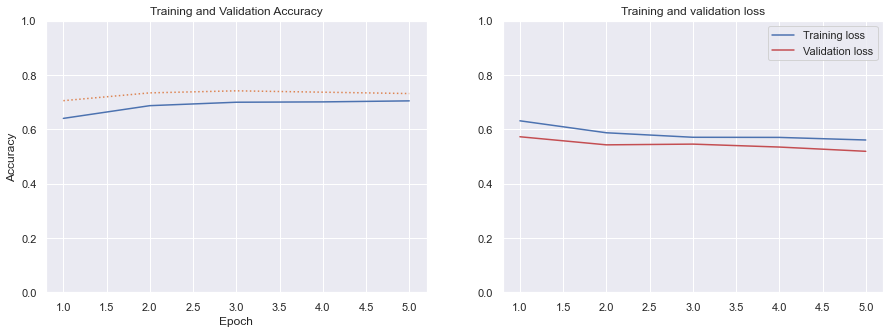

Accuracy: 71.95%


In [85]:
# create model
model_lstm_glove = lstm_model(embedding_glove, dropout=0.5, recurrent_dropout=0.5)

# fit model
start_time = time.time()
hist_lstm_glove = model_lstm_glove.fit(
    x_train, 
    y_train, 
    validation_split=0.1, 
    epochs=nb_epochs_init, 
    batch_size=128, 
    verbose = 0, 
    callbacks=[es]
)
nb_epochs_train = epochs_train(es.stopped_epoch, nb_epochs_init)
fit_time = time.time() - start_time

# evaluate model
start_time = time.time()
scores = model_lstm_glove.evaluate(x_test, y_test, verbose=0)
eval_time = time.time() - start_time

# plot history
plot_hist(hist_lstm_glove)
print("Accuracy: %.2f%%" % (scores[1] * 100))

La courbe de la validation est légèrement supérieure à celle de l'entrainement (et inversement pour les courbes loss).    
Pas d'overfitting.  
Augmentation du nombre d'epochs pour l'entrainement.  

In [61]:
# add to results
results = add_results(results, 'lstm', 'lem', 'glove', '0.5', nb_epochs_train, 20000, scores[1], fit_time, eval_time)


#### avec 20 epochs

Entrainement sur plus d'epochs

In [62]:
es = EarlyStopping(
    monitor='val_accuracy', 
    patience=2, 
    min_delta=0.001
)

nb_epochs_init = 20

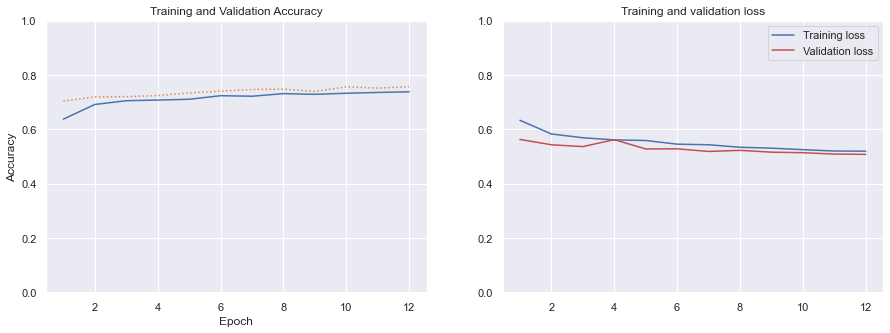

Accuracy: 72.65%


In [63]:

# create model
model_lstm_glove = lstm_model(embedding_glove, dropout=0.5, recurrent_dropout=0.5)

# fit model
start_time = time.time()
hist_lstm_glove = model_lstm_glove.fit(
    x_train, 
    y_train, 
    validation_split=0.1, 
    epochs=nb_epochs_init, 
    batch_size=128, 
    verbose = 0, 
    callbacks=[es]
)
nb_epochs_train = epochs_train(es.stopped_epoch, nb_epochs_init)
fit_time = time.time() - start_time

# evaluate model
start_time = time.time()
scores = model_lstm_glove.evaluate(x_test, y_test, verbose=0)
eval_time = time.time() - start_time

# plot history
plot_hist(hist_lstm_glove)
print("Accuracy: %.2f%%" % (scores[1] * 100))


Le score est un peu amélioré.  


In [64]:
# add to results
results = add_results(results, 'lstm', 'lem', 'glove', '0.5', nb_epochs_train, 20000, scores[1], fit_time, eval_time)


### 3.9 - BERT <a class="anchor" id="section_3_9"></a>

Test du modèle BERT.
Dans cette partie, le modèle pré-entrainé BERT est utilisé avec un fine-tuning sur nos données pour la tache d'analyse de sentiments.

L'entrainement (fine-tuning) est long. 
Utilisation d'un sample de 1000 échantillons.  

In [66]:
datas_sample_bert = sample_datas(1000)

Preprocessing

In [67]:

datas_bert = datas_sample_bert['text'].apply(lambda x: preprocess(x, 'lem'))
labels_bert = datas_sample_bert['label'].map(preprocess_label_dict)


Chargement du modèle BERT de base (sans la casse) spécifique à la classification de séqunces.  
Chargement du tokenizer BERT.

In [68]:
tf.get_logger().setLevel('ERROR')
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert_model = TFBertForSequenceClassification.from_pretrained('bert-base-uncased',num_labels=2)

All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Encode les textes avec bert tokenizer

In [69]:
input_ids=[]
attention_masks=[]

for sent in datas_bert:
    bert_inp=bert_tokenizer.encode_plus(sent,add_special_tokens = True,max_length =64,pad_to_max_length = True,return_attention_mask = True)
    input_ids.append(bert_inp['input_ids'])
    attention_masks.append(bert_inp['attention_mask'])

input_ids=np.asarray(input_ids)
attention_masks=np.array(attention_masks)
labels=np.array(labels_bert)

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
C:\Users\sylwi\anaconda3\envs\tf\lib\site-packages\transformers\tokenization_utils_base.py:2104: FutureWarning: The `pad_to_max_length` argument is deprecated and will be removed in a future version, use `padding=True` or `padding='longest'` to pad to the longest sequence in the batch, or use `padding='max_length'` to pad to a max length. In this case, you can give a specific length with `max_length` (e.g. `max_length=45`) or leave max_length to None to pad to the maximal input size of the model (e.g. 512 for Bert).
  warnings.warn(


Séparation données train et test

In [72]:
train_inp,val_inp,train_label,val_label,train_mask,val_mask=train_test_split(input_ids,labels,attention_masks,test_size=0.2)
print('Input shape {} Attention mask shape {} Input label shape {}'.format(input_ids.shape,attention_masks.shape,labels.shape))      

Input shape (1000, 64) Attention mask shape (1000, 64) Input label shape (1000,)


Compilation du modèle 

In [73]:
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
metric = tf.keras.metrics.SparseCategoricalAccuracy('accuracy')
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-5,epsilon=1e-08)

bert_model.compile(loss=loss,optimizer=optimizer,metrics=[metric])

Entrainement, évaluation du modèle BERT et affichage de l'historique d'entrainement

Epoch 1/5
25/25 [==============================] - 140s 5s/step - loss: 0.7016 - accuracy: 0.5225 - val_loss: 0.6844 - val_accuracy: 0.5500
Epoch 2/5
25/25 [==============================] - 121s 5s/step - loss: 0.6258 - accuracy: 0.6700 - val_loss: 0.6757 - val_accuracy: 0.6300
Epoch 3/5
25/25 [==============================] - 117s 5s/step - loss: 0.4848 - accuracy: 0.7937 - val_loss: 0.7225 - val_accuracy: 0.6350
Epoch 4/5
25/25 [==============================] - 117s 5s/step - loss: 0.3419 - accuracy: 0.8775 - val_loss: 0.7664 - val_accuracy: 0.6250
Epoch 5/5
7/7 [==============================] - 11s 2s/step - loss: 0.8241 - accuracy: 0.6400


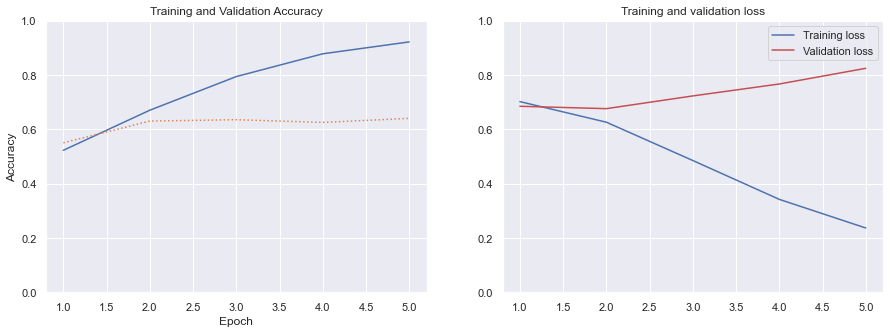

Accuracy: 64.00%


In [74]:

start_time = time.time()
hist_bert = bert_model.fit(
    [train_inp,train_mask],
    train_label,
    batch_size=32,
    epochs=5,
    validation_data=([val_inp,val_mask],val_label))
fit_time = time.time() - start_time

start_time = time.time()
scores = bert_model.evaluate([val_inp,val_mask], val_label,batch_size=32)
eval_time = time.time() - start_time

plot_hist(hist_bert)
print("Accuracy: %.2f%%" % (scores[1] * 100))


Le score est moins élevé.  
Phénomène d'overfitting.  
Le modèle est entrainé sur beaucoup moins de données que précédemment (LSTM...)

In [75]:
results = add_results(results, 'bert', 'lem', '', '', 5, 1000, scores[1], fit_time, eval_time)


### 3.10 - Synthèse des résultats <a class="anchor" id="section_3_10"></a>

In [134]:
# arrondi des temps et accuracy en pourcentage
results['fit_time']=results['fit_time'].round(decimals = 2)
results['eval_time']=results['eval_time'].round(decimals = 2)
results['accuracy']=results['accuracy']*100

In [135]:
results

,model,preprocess,embedding,dropout,epochs,sample,accuracy,fit_time,eval_time
0,Naive Bayes,clean_only,,,,20000,71.60,1.93,0.13
1,basic,clean_only,inline,,8,20000,69.65,6.02,2.22
2,lstm,clean_only,inline,0.2,3,20000,71.60,112.66,3.20
3,lstm,stem,inline,0.2,5,20000,71.05,203.31,3.41
4,lstm,lem,inline,0.2,4,20000,71.20,163.96,3.58
5,lstm,lem,w2vec,0.2,5,20000,72.10,265.82,5.74
6,lstm,lem,glove,0.2,5,20000,72.25,81.98,1.58
7,lstm,lem,glove,0.5,5,20000,71.95,80.56,1.40
8,lstm,lem,glove,0.5,12,20000,72.65,206.67,1.62
9,bert,lem,,,5,1000,64.00,613.69,10.77


Les modèles LSTM obtiennent un score légèrement plus élevé que le modèle basic.  
Les scores sont similaires sur les modèles LSTM inline quel que soit le type de preprocessing.  
Les scores sont un peu améliorés par l'utilisation de plongements de mots pré-entrainés.  

Les temps d'entrainement sont plus élevés avec les modèles LSTM que le modèle basic.  
Les temps d'entrainement avec LSTM sont inférieurs avec l'utilisation de glove (dimension 100).  

Le meilleur score est obtenu par LSTM - lemmatisation - glove - dropout 0.5 - 12 epochs.  

Les scores sont similaires à la baseline.  
Cependant les réseaux de neurones offrent de nombreuses possibilités de tuning  
qui permettraient probablement d'améliorer le score.  


De même, le score du modèle BERT est faible, ce modèle demande plus de ressources (durée entrainement, données d'entrainement...).

## 4 - Pipeline <a class="anchor" id="chapter4"></a>

Création d'un pipeline avec le preprocessing, la préparation des données et le modèle LSTM avec glove.  
Entrainement sur un échantillon de 1600 tweets.  
Cet échantillon est celui utilisé pour entrainer le pipeline directement sur Azure Machine Learning pour déploiement.  
Test simple du pipeline et avec un mock du web service

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from keras.wrappers.scikit_learn import KerasClassifier

def preprocess_pipe(text):

    text = clean_text(text) # clean
    tokens = word_tokenize(text) # tokenize
    tokens = remove_stop_words(tokens) # stop words    
    tokens = lemmatize(tokens) # lemmatize
    return " ".join(tokens)

class TokenizerTransformer(BaseEstimator, TransformerMixin, Tokenizer):

    def __init__(self, **tokenizer_params):
        Tokenizer.__init__(self, **tokenizer_params)

    def fit(self, X, y=None):
        self.fit_on_texts(X)
        return self

    def transform(self, X, y=None):
        X_transformed = self.texts_to_sequences(X)
        return X_transformed
  
    
class PadSequencesTransformer(BaseEstimator, TransformerMixin):

    def __init__(self, maxlen):
        self.maxlen = maxlen

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X_padded = pad_sequences(X, maxlen=self.maxlen)
        return X_padded    
    
class PreprocessTransformer(BaseEstimator, TransformerMixin):

    def __init__(self):
        None

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X_to_preprocess = pd.DataFrame(X)
        X_preprocessed = X_to_preprocess['text'].apply(lambda x: preprocess_pipe(x))
        return X_preprocessed    
    
def create_model(embedding):
    dropout = 0.5
    model = Sequential()
    model.add(embedding)
    model.add(LSTM(100, dropout=dropout, recurrent_dropout=dropout))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss = 'binary_crossentropy', optimizer='adam', metrics = ['accuracy'])
    
    return model    


#### Sample de 1600 tweets pour le test et pour azure

In [49]:
datas_sample_pipe = sample_datas(1600)

Export du sample pour utilisation du dataset sur azure

In [10]:
datas_sample_pipe.to_csv(data_path + "sentiment_datas_1600.csv", index=False)

#### Séparation des datas et labels

In [50]:
x_train_pipe = datas_sample_pipe['text']
y_train_pipe = np.array(datas_sample_pipe['label'].map({0:0, 4:1})).reshape(-1,1)


#### Création du pipeline

In [17]:
preproc = PreprocessTransformer()
my_tokenizer = TokenizerTransformer()
my_padder = PadSequencesTransformer(maxlen=100)
embedding_glove_pipe = glove_embedding_layer(glove, my_tokenizer.fit(preproc.transform(x_train_pipe)))

my_model = KerasClassifier(
               build_fn=create_model, 
               epochs=5,
               embedding=embedding_glove_pipe
)

pipeline = Pipeline([
              ('preprocess', preproc),
              ('tokenizer', my_tokenizer),
              ('padder', my_padder),
              ('model', my_model)
])



#### Entrainement du pipeline

In [19]:
pipeline.fit(x_train_pipe,y_train_pipe)

Epoch 1/5
50/50 [==============================] - 8s 120ms/step - loss: 0.6527 - accuracy: 0.6137
Epoch 2/5
50/50 [==============================] - 6s 119ms/step - loss: 0.5839 - accuracy: 0.6956
Epoch 3/5
50/50 [==============================] - 6s 121ms/step - loss: 0.5580 - accuracy: 0.7144
Epoch 4/5
50/50 [==============================] - 6s 123ms/step - loss: 0.5614 - accuracy: 0.7094
Epoch 5/5
50/50 [==============================] - 6s 124ms/step - loss: 0.5327 - accuracy: 0.7456


Pipeline(steps=[('preprocess', PreprocessTransformer()),
                ('tokenizer', TokenizerTransformer()),
                ('padder', PadSequencesTransformer(maxlen=100)),
                ('model',
                 <keras.wrappers.scikit_learn.KerasClassifier object at 0x0000021AE57FFCD0>)])

#### Test simple du pipeline

In [142]:
text_to_send = 'It is raining'
pipeline.predict({'text': [text_to_send]})


array([[0]], dtype=int64)

In [143]:
text_to_send = 'AI is for good'
pipeline.predict({'text': [text_to_send]})


array([[1]], dtype=int64)

#### Test du pipeline avec un mock du service web et les fonctions de formatage input et output (API)

In [58]:
import json

# mock of the azure web service
def ws_mock(raw_data):
    data = json.loads(raw_data)["data"]
    y_hat = pipeline.predict(data)
    return y_hat.tolist()

# text to send to the ws format
def format_text_to_send(text_to_send):
    datas_to_send={}
    datas_to_send['data'] = {'text': [text_to_send]}
    return json.dumps(datas_to_send)

# get the ws response
def format_ws_result(result_ws):
    res_dict = {0:'négatif', 1:'positif'}
    return res_dict[result_ws[0][0]]

def predict_sentiment(text):   
    formatted_text_to_send = format_text_to_send(text)    
    result_ws = ws_mock(formatted_text_to_send)
    sentiment_result = format_ws_result(result_ws)
    return sentiment_result



In [64]:
text1 = 'It is raining'
text2 = 'AI is for good'

sentiment_result = predict_sentiment(text1)
print(f'{text1} : Le sentiment est {sentiment_result}')

sentiment_result = predict_sentiment(text2)
print(f'{text2} : Le sentiment est {sentiment_result}')


It is raining : Le sentiment est négatif
AI is for good : Le sentiment est positif


## 5 - Conclusion <a class="anchor" id="chapter5"></a>

Les réseaux de neurones offrent de nombreuses possibilités de tuning.   
Ils demandent des ressources pour l'entrainement, en temps et puissance de calcul.  
Les plongements de mots pré-entrainés permettent d'améliorer l'analyse de sentiments.  
Le modèle LSTM avec le plongement de mots GloVe a obtenu les meilleures résultats.  
